## 10 - Annotations & Text

### Why annotate?
Annotations **guide the reader's eye** to the most important parts of your chart - a peak, a dip, a threshold, an outlier. Without annotations, viewers have to figure out what matters. With annotations, you tell them.

### plt.text() - place text anywhere
```python
plt.text(x, y, 'Some label',
         ha='center',     # horizontal: 'left', 'center', 'right'
         va='bottom',     # vertical:   'top', 'center', 'bottom'
         fontsize=10,
         color='red',
         fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
```

### plt.annotate() - text with an arrow
```python
plt.annotate('Peak!',
             xy=(x_point, y_point),       # arrow TIP — the point you're marking
             xytext=(x_text, y_text),     # where the text label sits
             fontsize=10,
             arrowprops=dict(
                 arrowstyle='->',
                 color='black',
                 lw=1.5))
```

### Reference lines and bands
```python
plt.axhline(y=70, color='red', ls='--', lw=1.5, label='Pass mark')
plt.axvline(x=5,  color='blue', ls=':')

plt.axhspan(ymin=80, ymax=100, alpha=0.1, color='green', label='Distinction zone')
plt.axvspan(xmin=8,  xmax=10,  alpha=0.1, color='orange')
```


In [1]:
import matplotlib.pyplot as plt

In [2]:
import numpy as np

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
score  = [60, 58, 63, 67, 65, 71, 74, 72, 78, 82, 85, 88]

### Plot 1 : Annotate dip and peak 

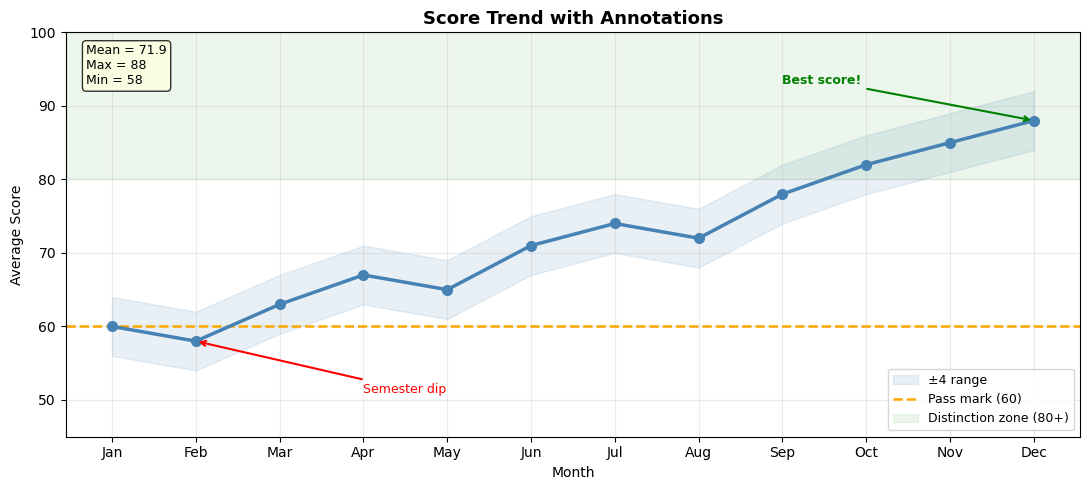

In [4]:
plt.figure(figsize=(11, 5))

plt.plot(months, score, color='steelblue', lw=2.5, marker='o', ms=7, zorder=3)
plt.fill_between(months, [s - 4 for s in score], [s + 4 for s in score],
                 alpha=0.12, color='steelblue', label='±4 range')

# Reference lines
plt.axhline(y=60, color='orange', ls='--', lw=1.8, label='Pass mark (60)')
plt.axhspan(80, 100, alpha=0.07, color='green', label='Distinction zone (80+)')

# Annotate the dip
plt.annotate('Semester dip',
             xy=(1, 58), xytext=(3, 51),
             fontsize=9, color='red',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# Annotate the peak
plt.annotate('Best score!',
             xy=(11, 88), xytext=(8, 93),
             fontsize=9, color='green', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

# Stats text box
stats_text = f'Mean = {np.mean(score):.1f}\nMax = {max(score)}\nMin = {min(score)}'
plt.text(0.02, 0.97, stats_text, transform=plt.gca().transAxes,
         fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.title('Score Trend with Annotations', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Score')

plt.ylim(45, 100)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Plot 2 : Labels on a bar chart

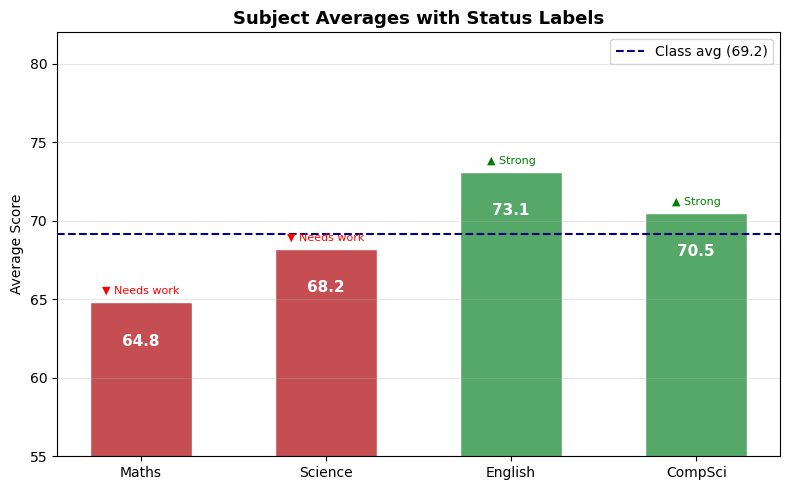

In [5]:
subjects = ['Maths', 'Science', 'English', 'CompSci']
avgs     = [64.8, 68.2, 73.1, 70.5]
class_avg = sum(avgs) / len(avgs)

bar_colors = ['#C44E52' if v < class_avg else '#55A868' for v in avgs]

plt.figure(figsize=(8, 5))
plt.bar(subjects, avgs, color=bar_colors, edgecolor='white', width=0.55)

# Value label INSIDE bar
for i, val in enumerate(avgs):
    plt.text(i, val - 2, f'{val:.1f}', ha='center', va='top',
             fontsize=11, fontweight='bold', color='white')

# Status label ABOVE bar
for i, val in enumerate(avgs):
    status = '▲ Strong' if val >= class_avg else '▼ Needs work'
    col    = 'green' if val >= class_avg else 'red'
    plt.text(i, val + 0.4, status, ha='center', va='bottom', fontsize=8, color=col)

plt.axhline(class_avg, color='navy', ls='--', lw=1.5, label=f'Class avg ({class_avg:.1f})')
plt.title('Subject Averages with Status Labels', fontsize=13, fontweight='bold')
plt.ylabel('Average Score')

plt.ylim(55, 82)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()